IMPORT LIBRARIES

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

LOAD DATASET

In [41]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,0


BASIC EXPLORATION

In [42]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
print(df.info())

print("\nSummary:")
print(df.describe())

Shape: (1025, 13)

Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'target'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  target    1025 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 104.2 KB
None

Summary:
               age          sex           cp     trest

CHECK MISSING VALUES

In [43]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
target      0
dtype: int64

In [44]:
#no null values

CHECK DUPLICATES

In [45]:
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicate Rows: 723


OUTLIER DETECTION AND CORRECTON

In [46]:
num_cols= df.select_dtypes(include=['int'])

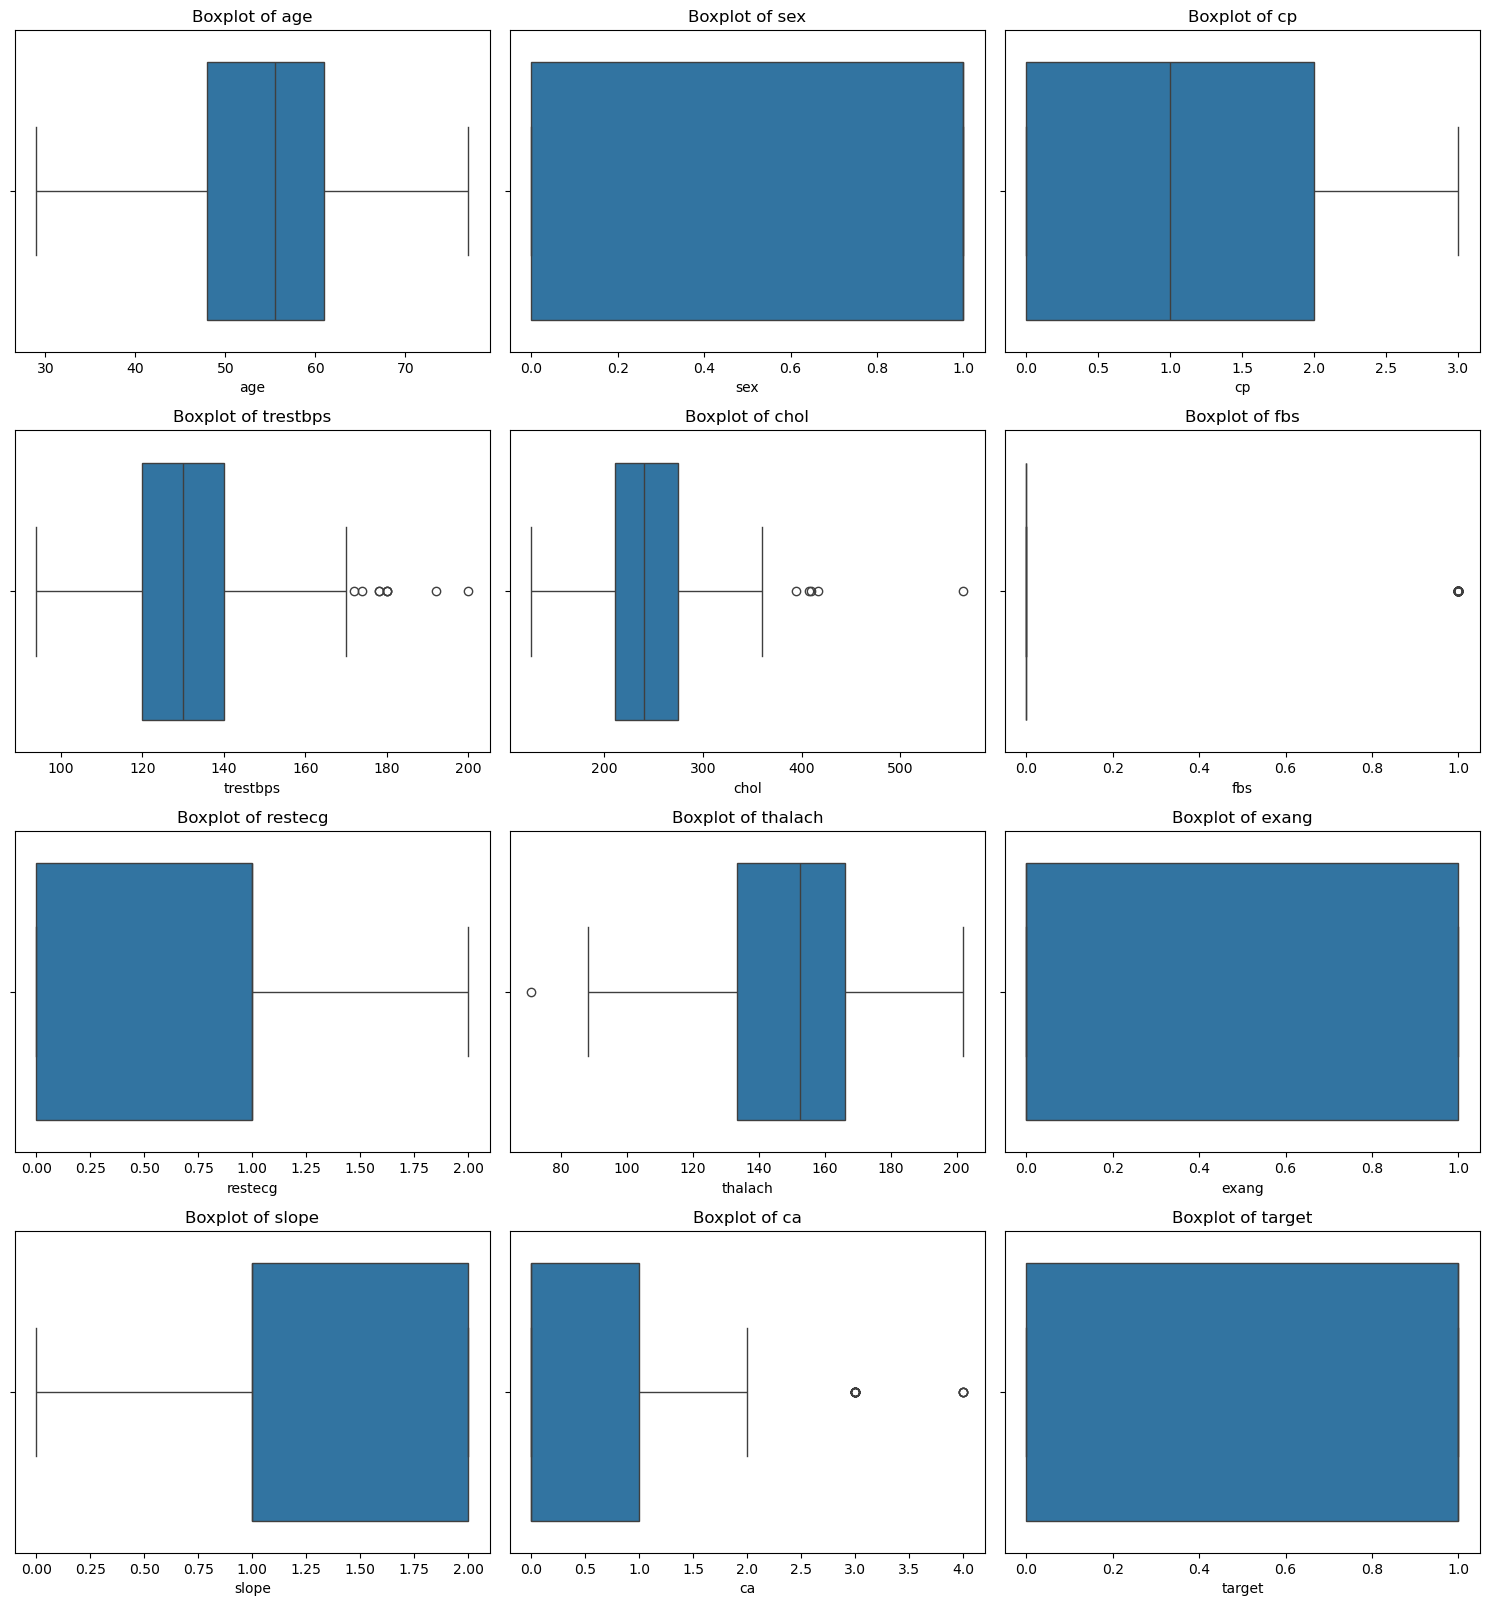

In [47]:
import math

n_cols = len(num_cols)

cols = 3   
rows = math.ceil(n_cols / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [48]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] > upper, upper, df[col])
    df[col] = np.where(df[col] < lower, lower, df[col])

print("Outliers Treated Successfully")

Outliers Treated Successfully


TARGET DISTRIBUTION

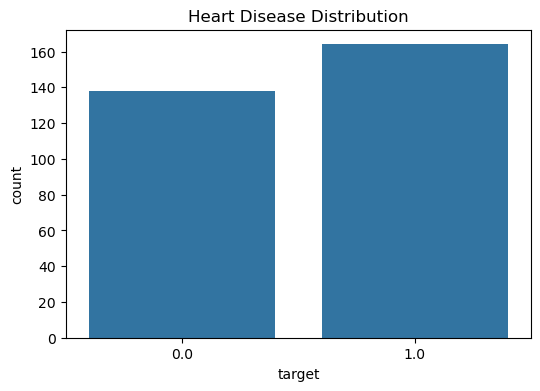

In [50]:
plt.figure(figsize=(6,4))

sns.countplot(x='target', data=df)

plt.title("Heart Disease Distribution")

plt.show()

AGE DISTRIBUTION

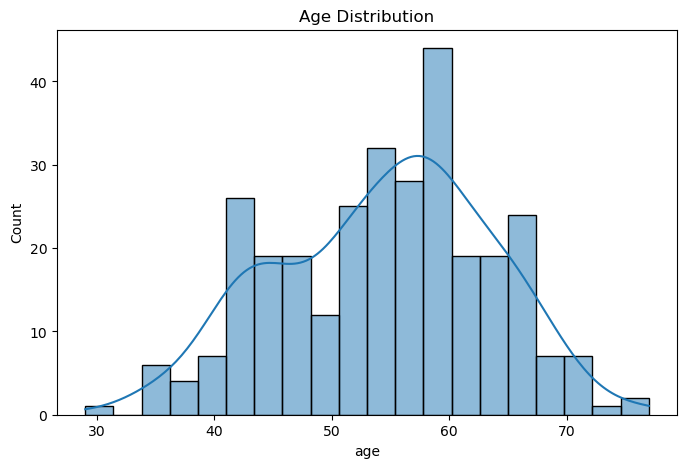

In [51]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20, kde=True)

plt.title("Age Distribution")

plt.show()

CHOLESTEROL DISTRIBUTION


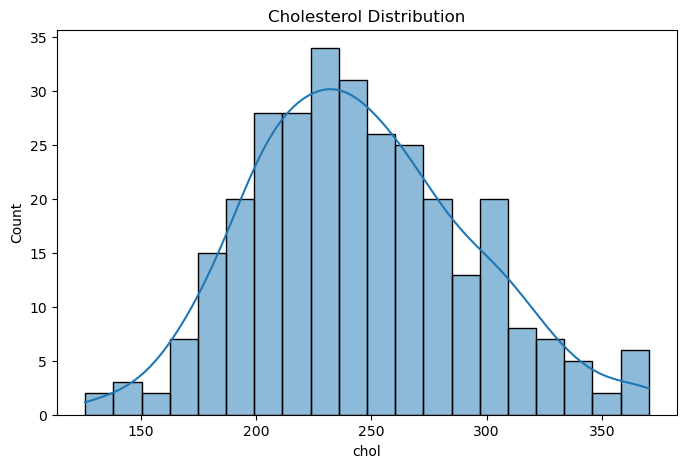

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(df['chol'], bins=20, kde=True)

plt.title("Cholesterol Distribution")

plt.show()

HEART DISEASE BY GENDER

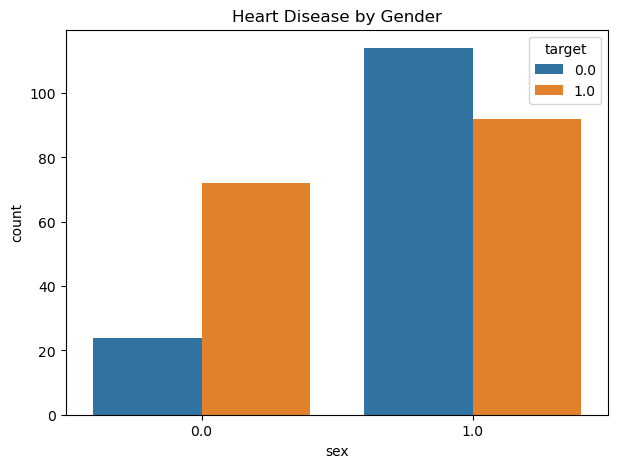

In [53]:
plt.figure(figsize=(7,5))

sns.countplot(x='sex', hue='target', data=df)

plt.title("Heart Disease by Gender")

plt.show()

CHEST PAIN ANALYSIS

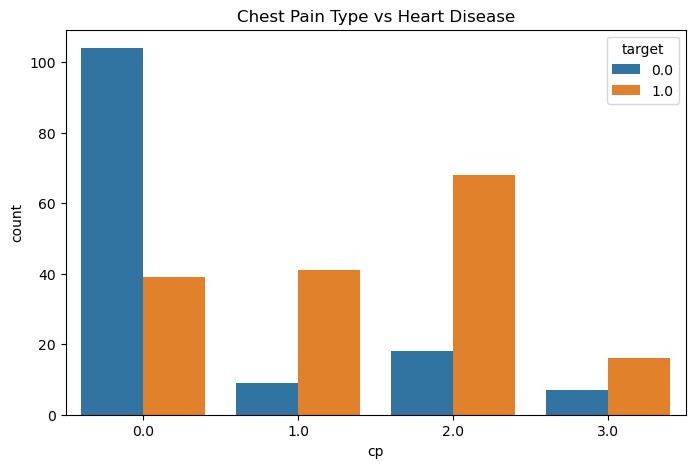

In [54]:
plt.figure(figsize=(8,5))

sns.countplot(x='cp', hue='target', data=df)

plt.title("Chest Pain Type vs Heart Disease")

plt.show()

CORRELATION HEATMAP

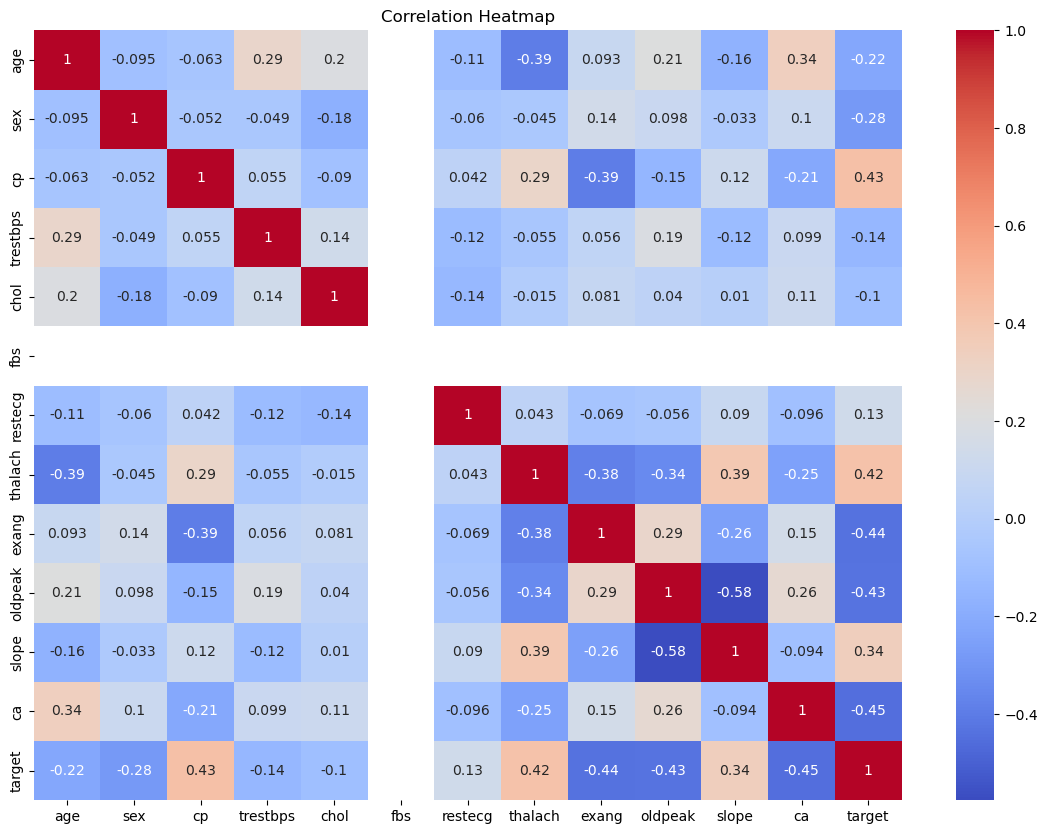

In [55]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

FEATURE ENGINEERING

In [56]:
bins = [20, 35, 50, 65, 80]

labels = ['Young', 'Adult', 'Middle Age', 'Senior']

df['Age_Group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels
)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,target,Age_Group
0,52.0,1.0,0.0,125.0,212.0,0.0,1.0,168.0,0.0,1.0,2.0,2.0,0.0,Middle Age
1,53.0,1.0,0.0,140.0,203.0,0.0,0.0,155.0,1.0,3.1,0.0,0.0,0.0,Middle Age
2,70.0,1.0,0.0,145.0,174.0,0.0,1.0,125.0,1.0,2.6,0.0,0.0,0.0,Senior
3,61.0,1.0,0.0,148.0,203.0,0.0,1.0,161.0,0.0,0.0,2.0,1.0,0.0,Middle Age
4,62.0,0.0,0.0,138.0,294.0,0.0,1.0,106.0,0.0,1.9,1.0,2.5,0.0,Middle Age


ENCODE CATEGORICAL VARIABLES

In [58]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,target,Age_Group_Adult,Age_Group_Middle Age,Age_Group_Senior
0,52.0,1.0,0.0,125.0,212.0,0.0,1.0,168.0,0.0,1.0,2.0,2.0,0.0,False,True,False
1,53.0,1.0,0.0,140.0,203.0,0.0,0.0,155.0,1.0,3.1,0.0,0.0,0.0,False,True,False
2,70.0,1.0,0.0,145.0,174.0,0.0,1.0,125.0,1.0,2.6,0.0,0.0,0.0,False,False,True
3,61.0,1.0,0.0,148.0,203.0,0.0,1.0,161.0,0.0,0.0,2.0,1.0,0.0,False,True,False
4,62.0,0.0,0.0,138.0,294.0,0.0,1.0,106.0,0.0,1.9,1.0,2.5,0.0,False,True,False


FEATURE & TARGET SPLIT

In [61]:
X = df.drop('target', axis=1)

y = df['target']

TRAIN TEST SPLIT

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

FEATURE SCALING

In [64]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Model

In [ ]:
#Logistic Regression
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:")

print(accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy:
0.7704918032786885


In [68]:
#DECISION TREE
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:")

print(accuracy_score(y_test, dt_pred))

Decision Tree Accuracy:
0.7213114754098361


In [72]:
#Random forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:")

print(accuracy_score(y_test, rf_pred))

Random Forest Accuracy:
0.7868852459016393


In [73]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

         0.0       0.83      0.75      0.79        32
         1.0       0.75      0.83      0.79        29

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61



CONFUSION MATRIX

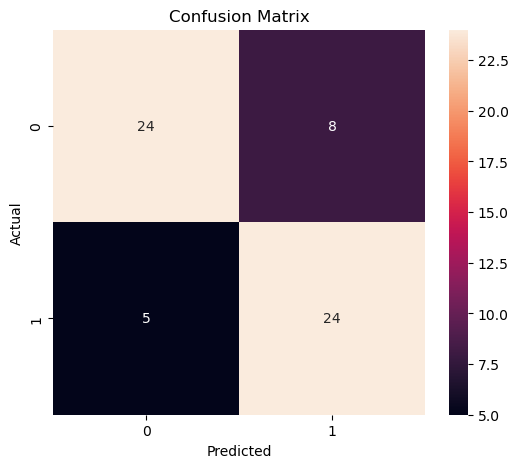

In [75]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

FEATURE IMPORTANCE

In [76]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
2,cp,0.148122
7,thalach,0.133577
9,oldpeak,0.128154
11,ca,0.109114
0,age,0.087257
4,chol,0.079989
3,trestbps,0.079495
8,exang,0.061261
10,slope,0.059037
1,sex,0.050644


FEATURE IMPORTANCE GRAPH

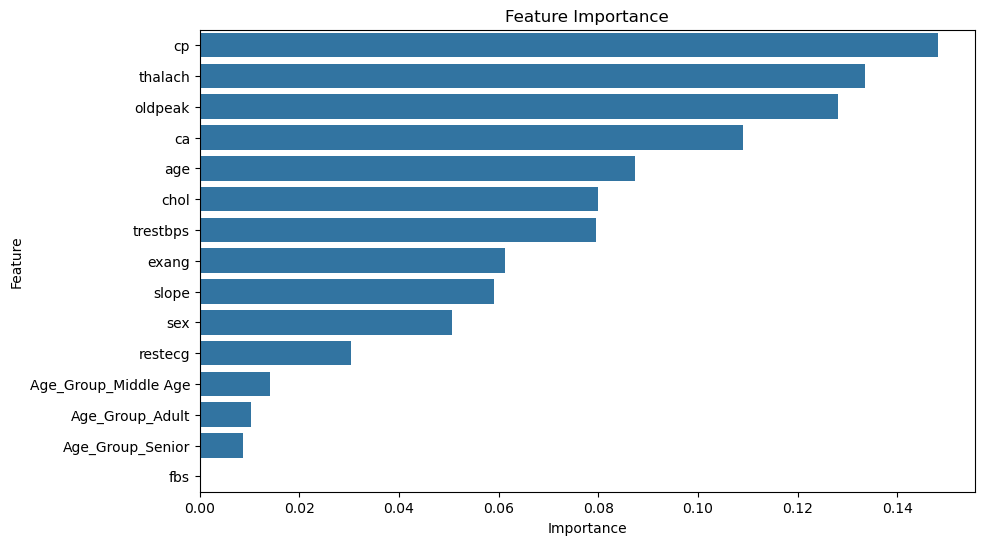

In [77]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()

MODEL COMPARISON

In [78]:
models = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

models

,Model,Accuracy
0,Logistic Regression,0.770492
1,Decision Tree,0.721311
2,Random Forest,0.786885


MODEL COMPARISON GRAPH

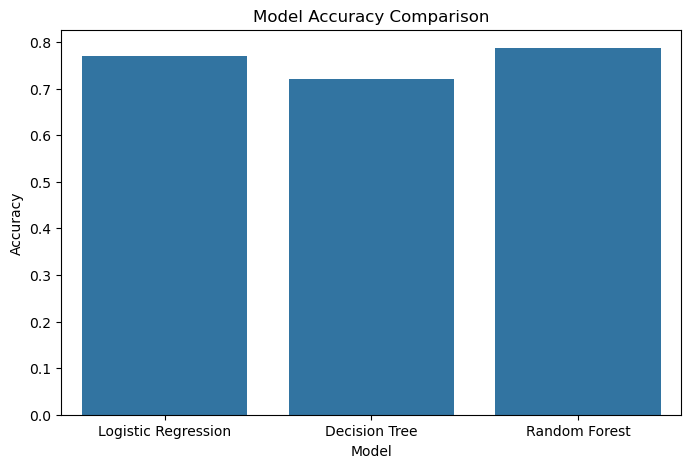

In [79]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=models
)

plt.title("Model Accuracy Comparison")

plt.show()

PROJECT INSIGHTS

1. Chest pain strongly affects heart disease.

2. Older people have higher disease probability.

3. Cholesterol and blood pressure are important indicators.

4. Random Forest performed best among models.

5. Maximum heart rate is an important predictor.

